In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print("Dataset shape:", df.shape)
print("Number of data points:", df.shape[0])
print("Number of input features:", df.shape[1] - 1)
print("Target feature: y")
df.info()

Dataset shape: (41188, 21)
Number of data points: 41188
Number of input features: 20
Target feature: y
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41

In [4]:
num_data = df.select_dtypes(include='number')
cat_data = df.select_dtypes(include='object')

num_col = num_data.columns.tolist()
cat_col = cat_data.columns.tolist()
cat_input = [col for col in cat_col if col != 'y']

print("Numerical features:")
print(num_col)
print("Total:", len(num_col))

print("\nCategorical input features:")
print(cat_input)
print("Total:", len(cat_input))

Numerical features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Total: 10

Categorical input features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Total: 10


In [5]:
num_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [6]:
cat_data.describe().T

,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


In [7]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Duplicate rows: 12


In [8]:
unknown_data = []

for col in cat_input:
    count = (df[col].astype(str).str.lower() == 'unknown').sum()
    if count > 0:
        percent = round((count / len(df)) * 100, 2)
        unknown_data.append([col, count, percent])

unknown_df = pd.DataFrame(
    unknown_data,
    columns=['Feature', 'Unknown Count', 'Percentage']
)
unknown_df

,Feature,Unknown Count,Percentage
0,job,330,0.80
1,marital,80,0.19
2,education,1731,4.20
3,default,8597,20.87
4,housing,990,2.40
5,loan,990,2.40


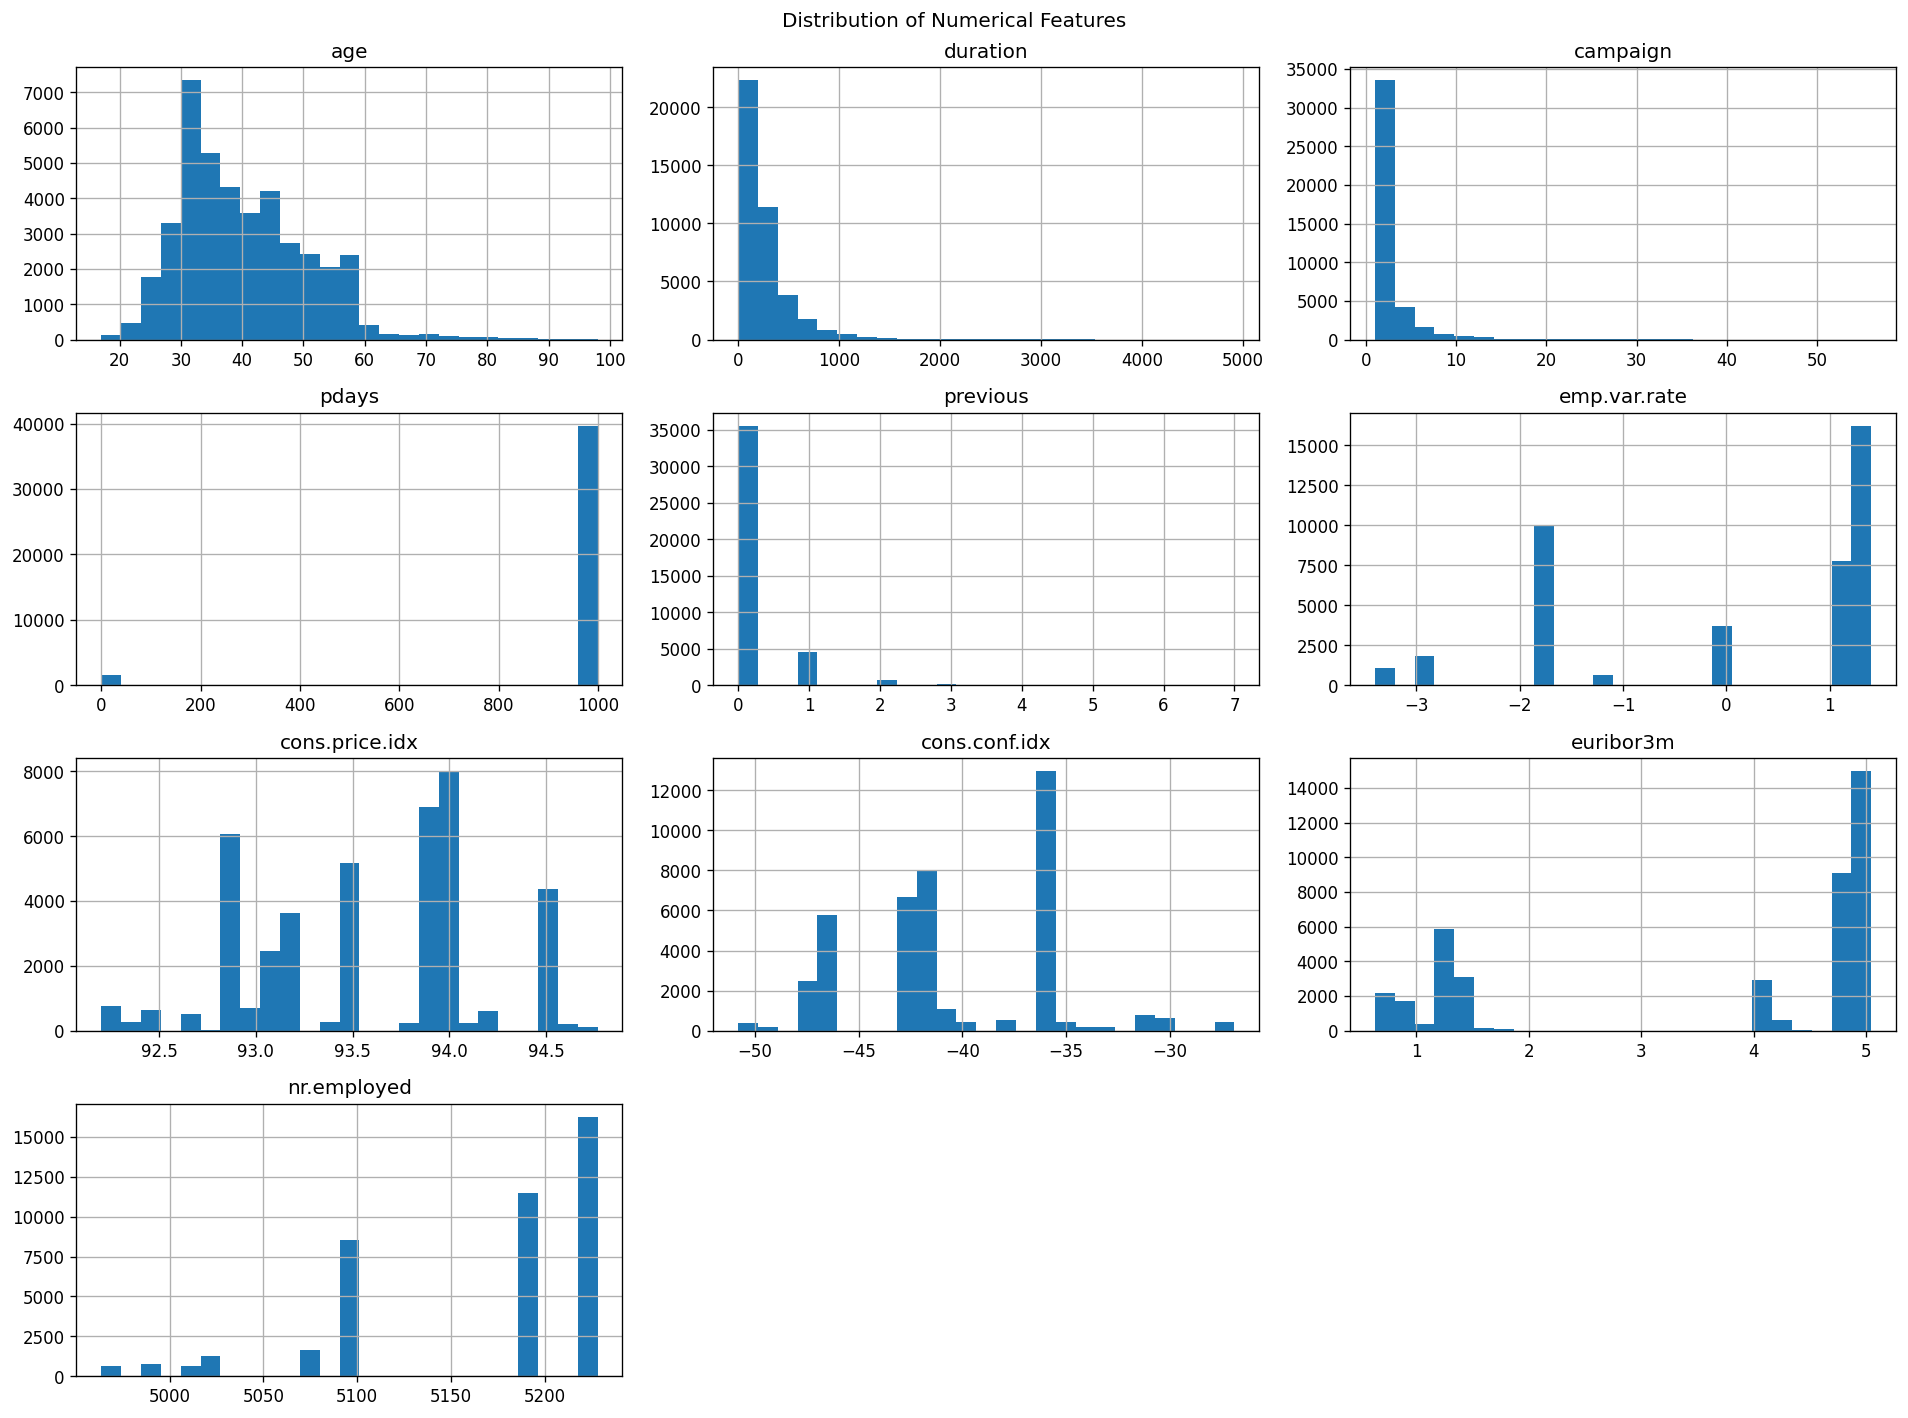

In [9]:
num_data.hist(figsize=(16, 12), bins=25)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

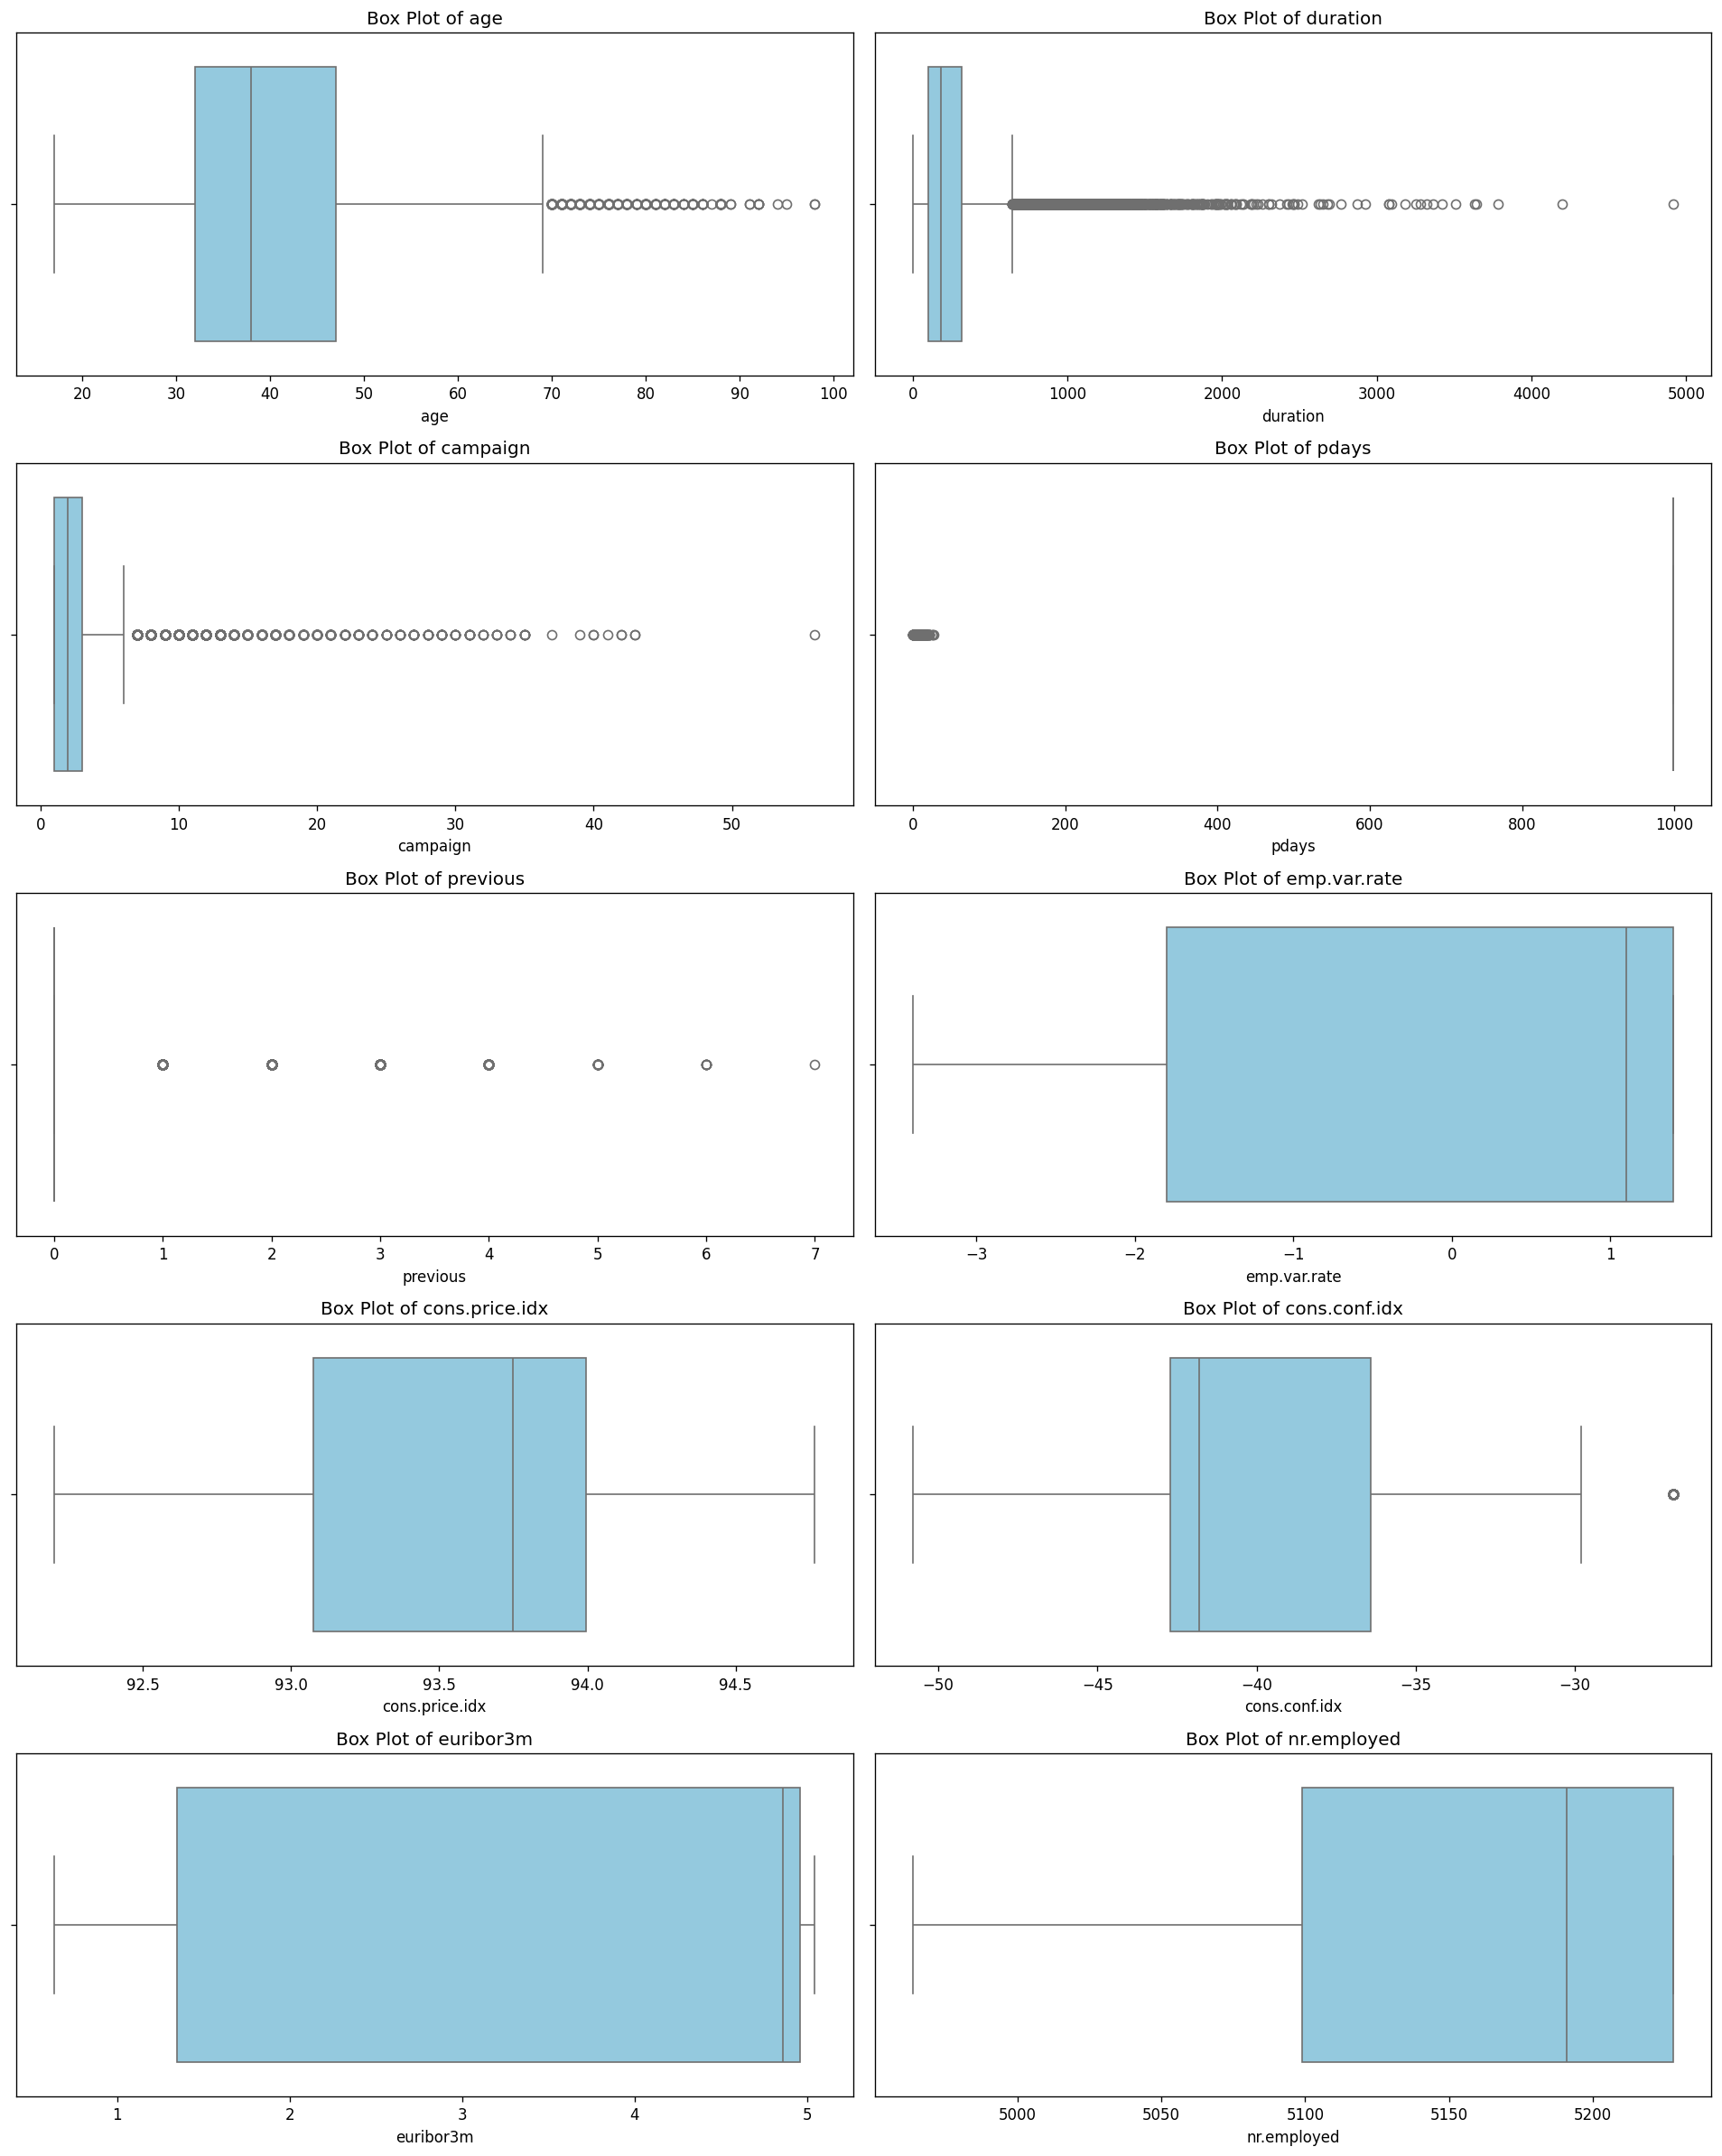

In [10]:
plt.figure(figsize=(16, 20))

for i, col in enumerate(num_col, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title("Box Plot of " + col)

plt.tight_layout()
plt.show()

  Class  Count  Percentage
0    no  36548       88.73
1   yes   4640       11.27


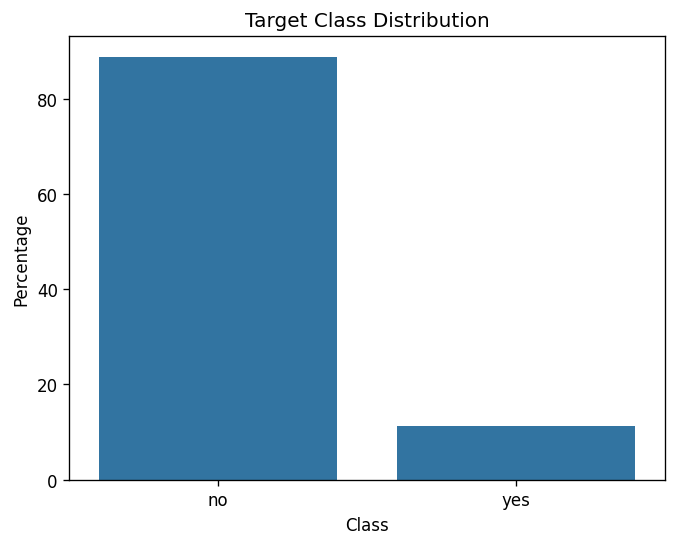

In [11]:
class_count = df['y'].value_counts()
class_percent = df['y'].value_counts(normalize=True) * 100

class_df = pd.DataFrame({
    'Class': class_count.index,
    'Count': class_count.values,
    'Percentage': class_percent.values.round(2)
})

print(class_df)

sns.barplot(data=class_df, x='Class', y='Percentage')
plt.title("Target Class Distribution")
plt.ylabel("Percentage")
plt.show()

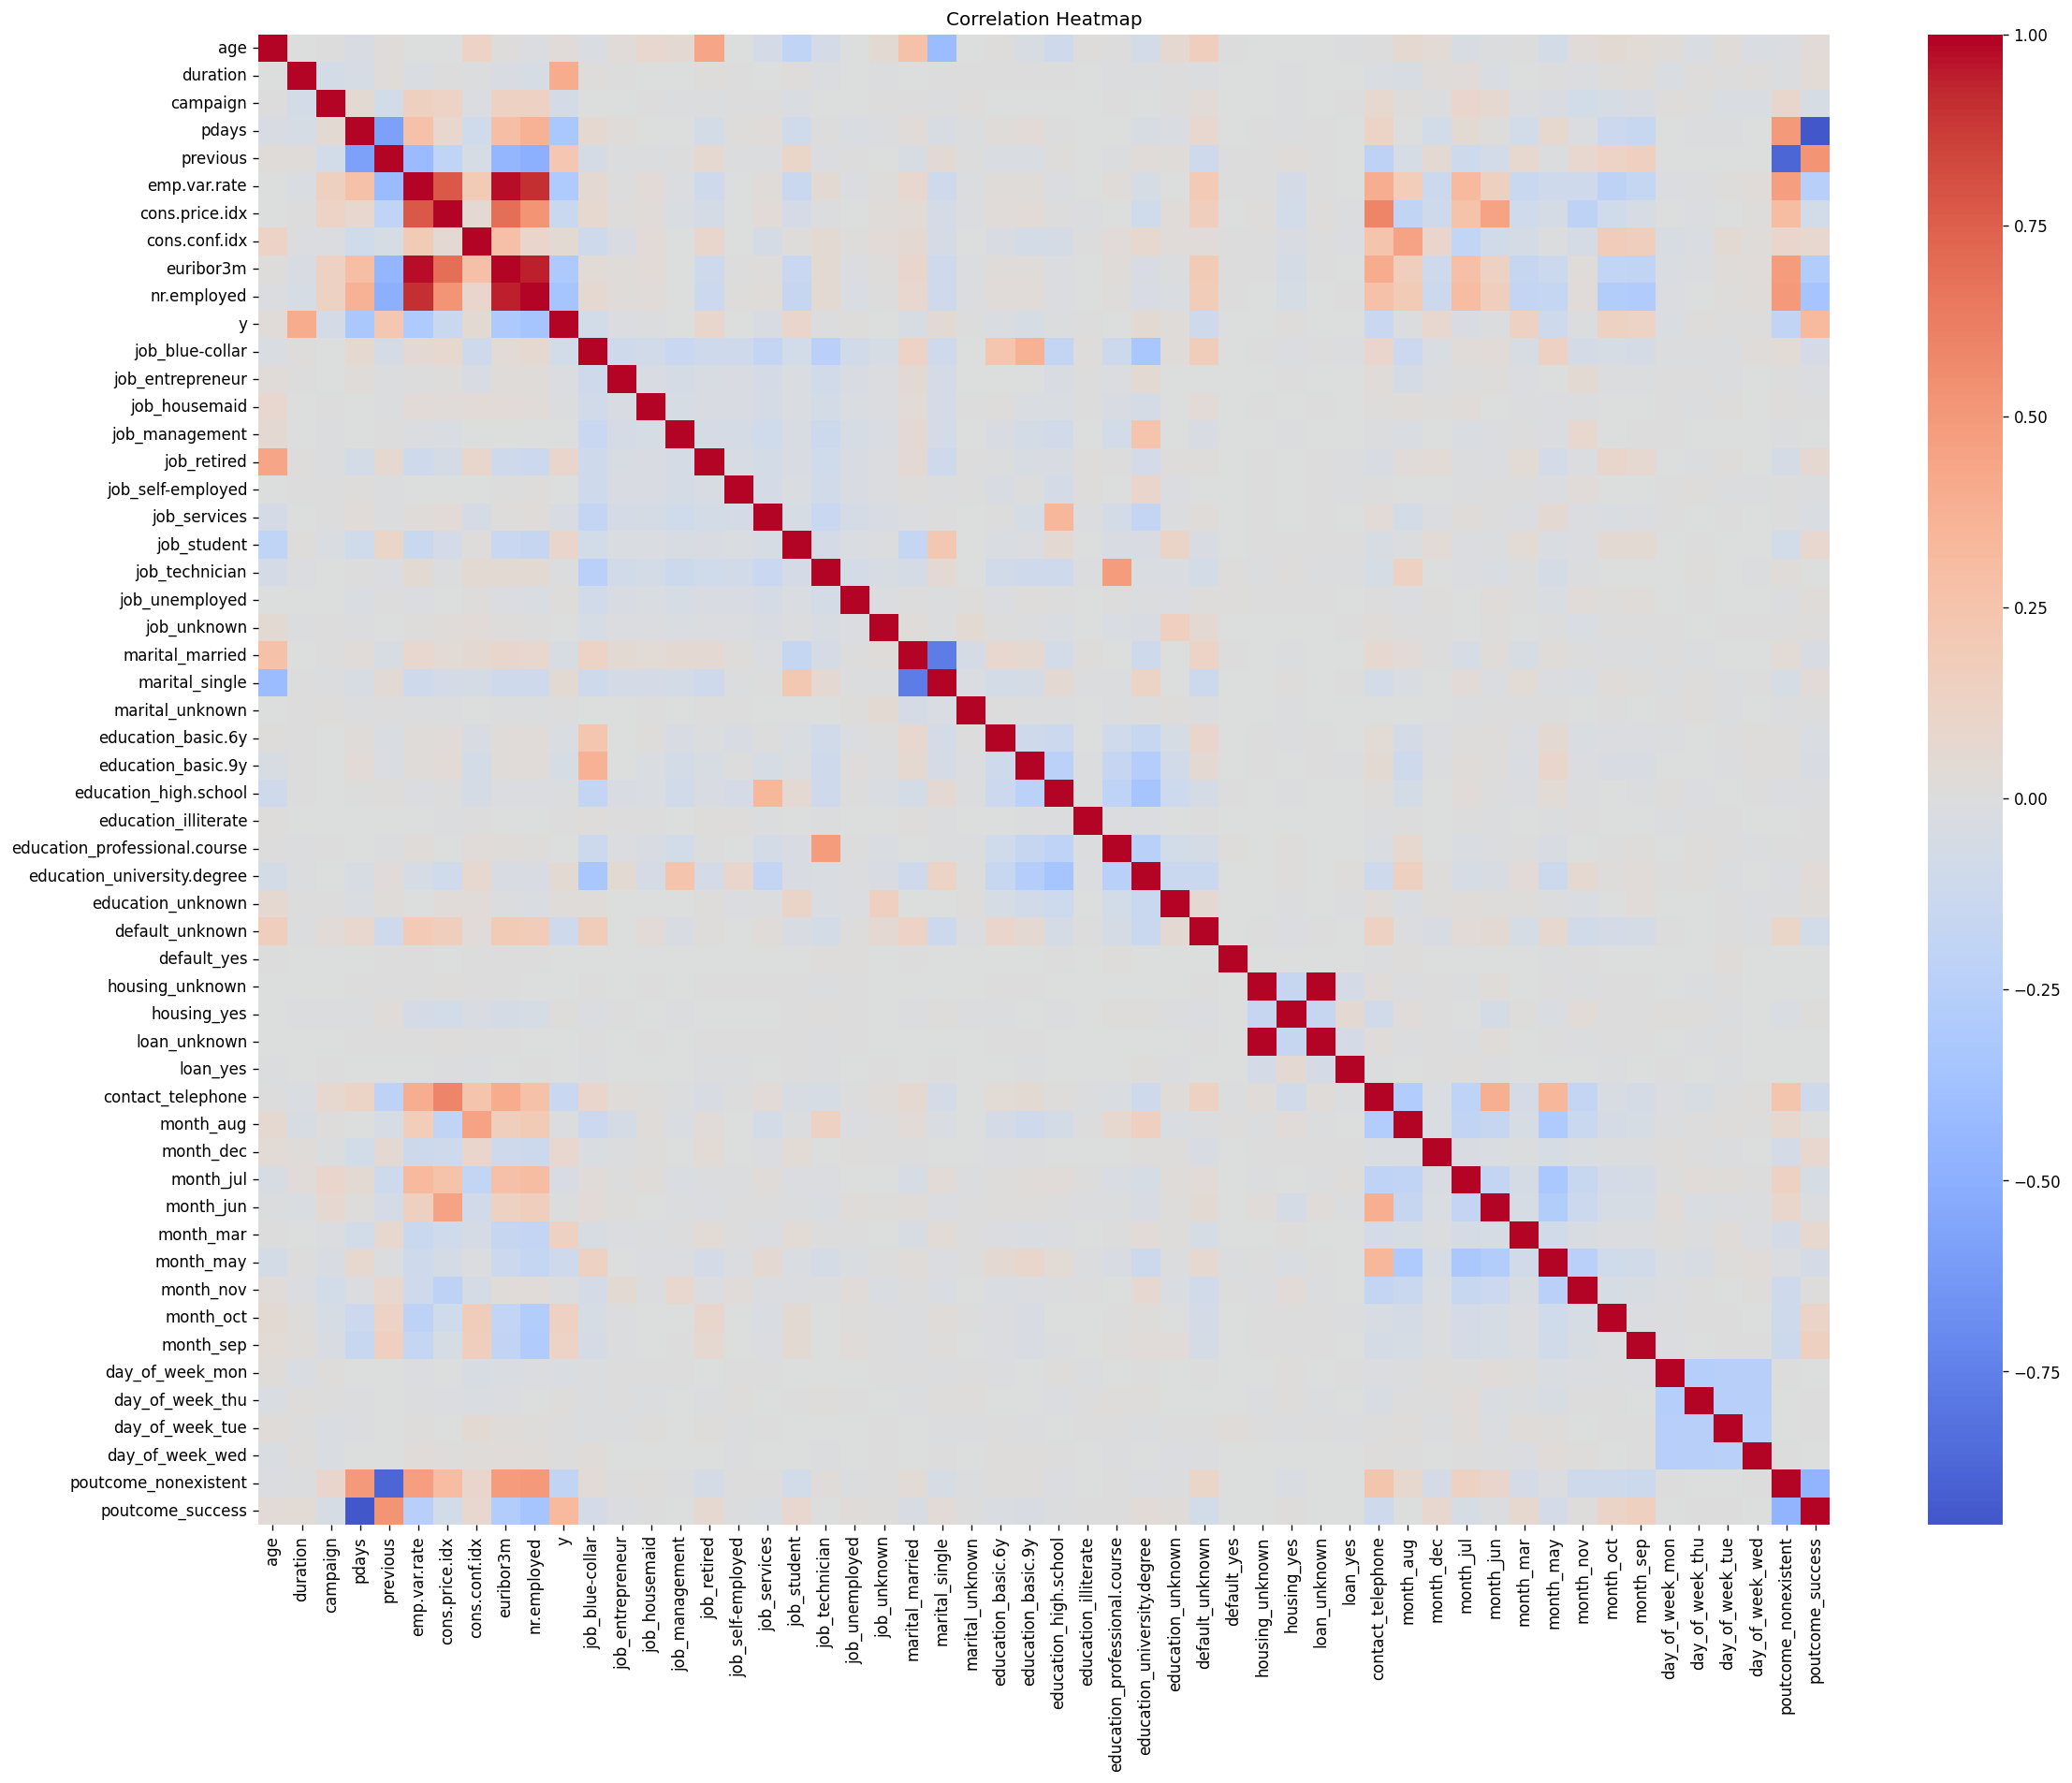

In [12]:
corr_df = df.drop_duplicates().copy()
corr_df['y'] = corr_df['y'].map({'no': 0, 'yes': 1})
corr_df = pd.get_dummies(corr_df, drop_first=True, dtype=int)

corr = corr_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [13]:
target_corr = corr['y'].drop('y')
top_index = target_corr.abs().sort_values(ascending=False).head(15).index
top_corr = target_corr.loc[top_index]
top_corr.to_frame(name='Correlation with y')

,Correlation with y
duration,0.405297
nr.employed,-0.354669
pdays,-0.324948
poutcome_success,0.316302
euribor3m,-0.307740
emp.var.rate,-0.298289
previous,0.230202
poutcome_nonexistent,-0.193522
contact_telephone,-0.144774
month_mar,0.144027


In [14]:
# remove duplicate rows
data = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", data.shape[0])

# convert the target to 0 and 1
data['y'] = data['y'].map({'no': 0, 'yes': 1})

# separate input and output
X = data.drop('y', axis=1)
y = data['y']

# one-hot encoding
X = pd.get_dummies(X, drop_first=True, dtype=int)
print("Number of encoded features:", X.shape[1])

Rows after removing duplicates: 41176
Number of encoded features: 53


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)
print("\nTraining class percentage:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTesting class percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training shape: (32940, 53)
Testing shape: (8236, 53)

Training class percentage:
y
0    88.734062
1    11.265938
Name: proportion, dtype: float64

Testing class percentage:
y
0    88.732394
1    11.267606
Name: proportion, dtype: float64


In [16]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [17]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)
nb_prob = nb.predict_proba(X_test_scaled)[:, 1]

In [18]:
nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=128,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.20,
    n_iter_no_change=5,
    random_state=42
)

nn.fit(X_train_scaled, y_train)
nn_pred = nn.predict(X_test_scaled)
nn_prob = nn.predict_proba(X_test_scaled)[:, 1]

print("Training iterations:", nn.n_iter_)

Training iterations: 9


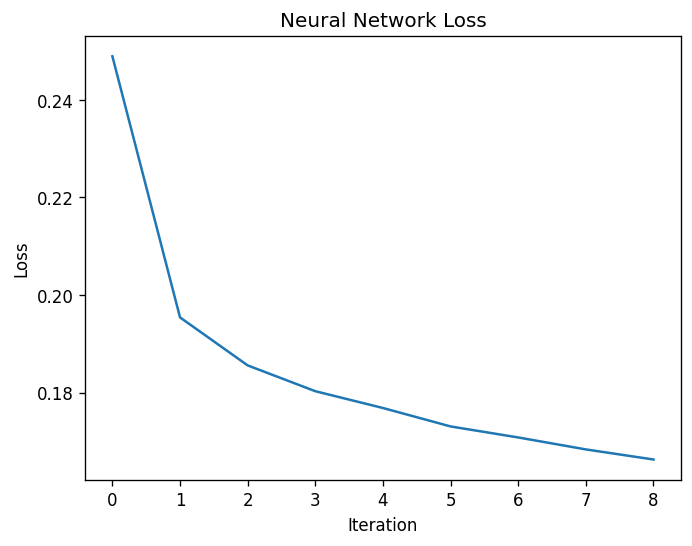

In [19]:
plt.plot(nn.loss_curve_)
plt.title("Neural Network Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [20]:
result = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gaussian Naive Bayes', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, nn_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, nn_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, nn_pred)
    ],
    'AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, nb_prob),
        roc_auc_score(y_test, nn_prob)
    ]
})

result.set_index('Model').round(4)

,Accuracy,Precision,Recall,AUC
Model,,,,
Logistic Regression,0.9093,0.6501,0.4224,0.9390
Gaussian Naive Bayes,0.7591,0.2965,0.8287,0.8508
Neural Network,0.9109,0.6359,0.4892,0.9392


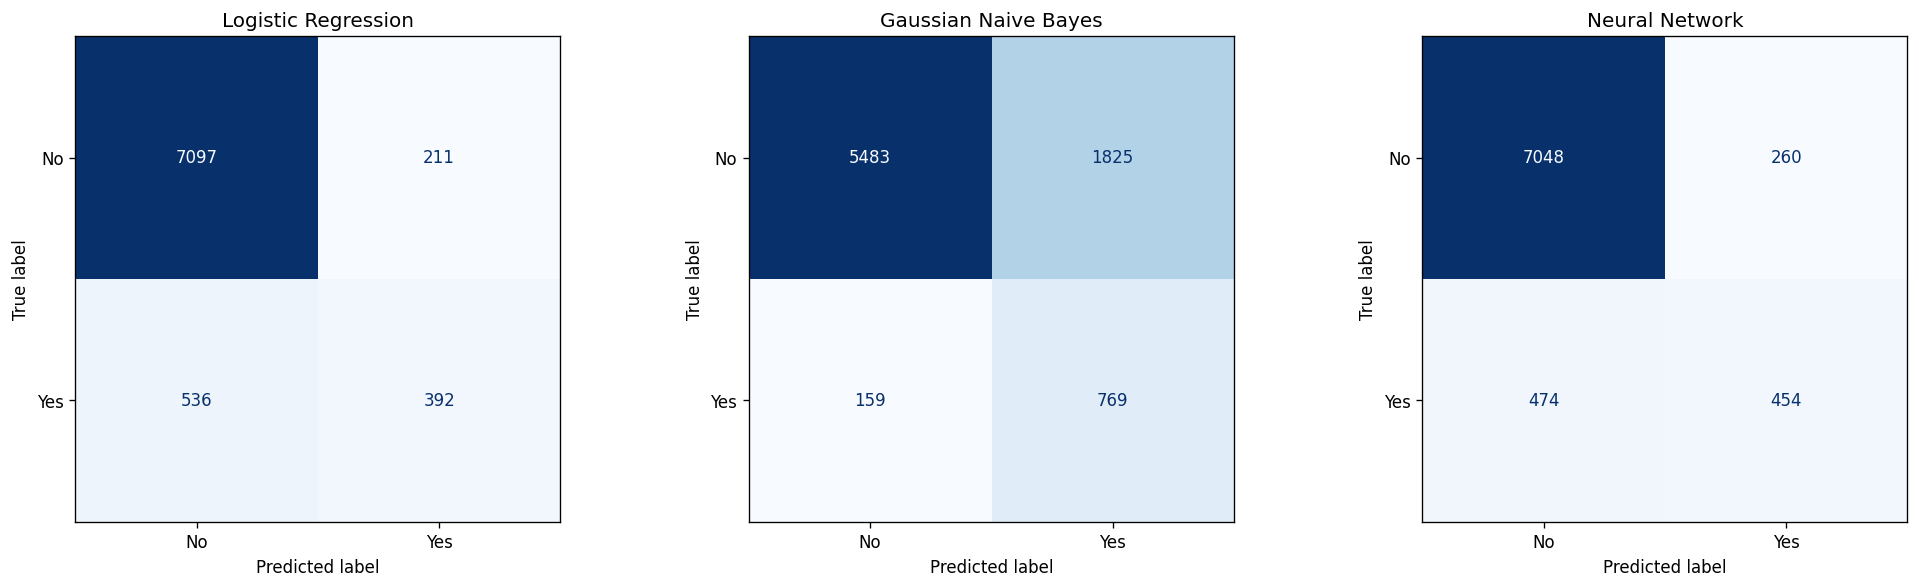

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=['No', 'Yes']).plot(
    cmap='Blues', ax=ax[0], colorbar=False
)
ax[0].set_title("Logistic Regression")

cm_nb = confusion_matrix(y_test, nb_pred)
ConfusionMatrixDisplay(cm_nb, display_labels=['No', 'Yes']).plot(
    cmap='Blues', ax=ax[1], colorbar=False
)
ax[1].set_title("Gaussian Naive Bayes")

cm_nn = confusion_matrix(y_test, nn_pred)
ConfusionMatrixDisplay(cm_nn, display_labels=['No', 'Yes']).plot(
    cmap='Blues', ax=ax[2], colorbar=False
)
ax[2].set_title("Neural Network")

plt.tight_layout()
plt.show()

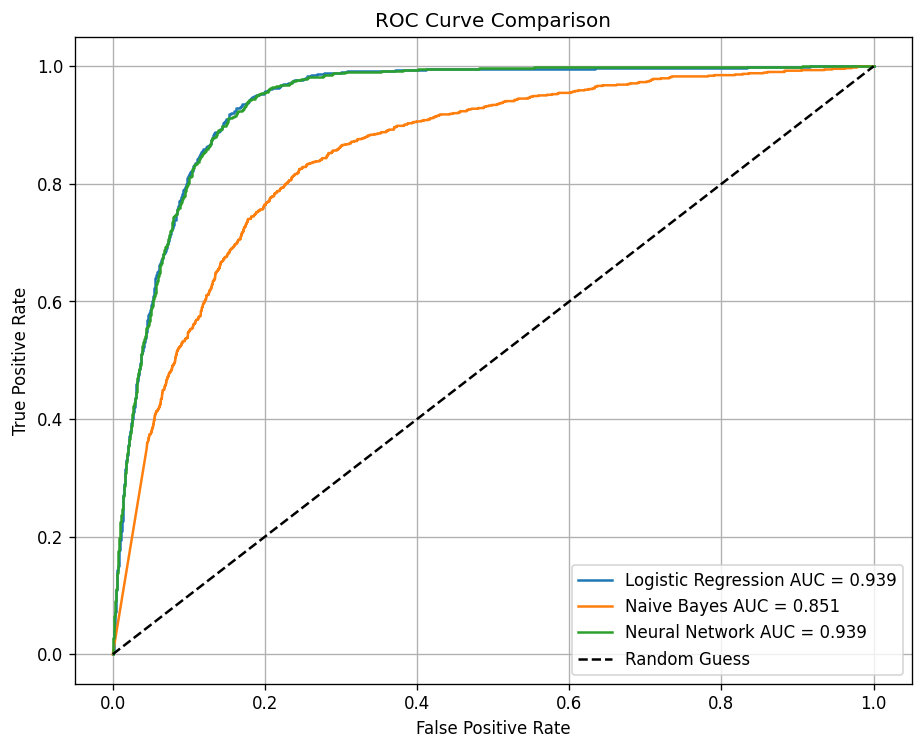

In [22]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_prob)

plt.figure(figsize=(9, 7))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression AUC = {:.3f}'.format(roc_auc_score(y_test, lr_prob)))
plt.plot(fpr_nb, tpr_nb, label='Naive Bayes AUC = {:.3f}'.format(roc_auc_score(y_test, nb_prob)))
plt.plot(fpr_nn, tpr_nn, label='Neural Network AUC = {:.3f}'.format(roc_auc_score(y_test, nn_prob)))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

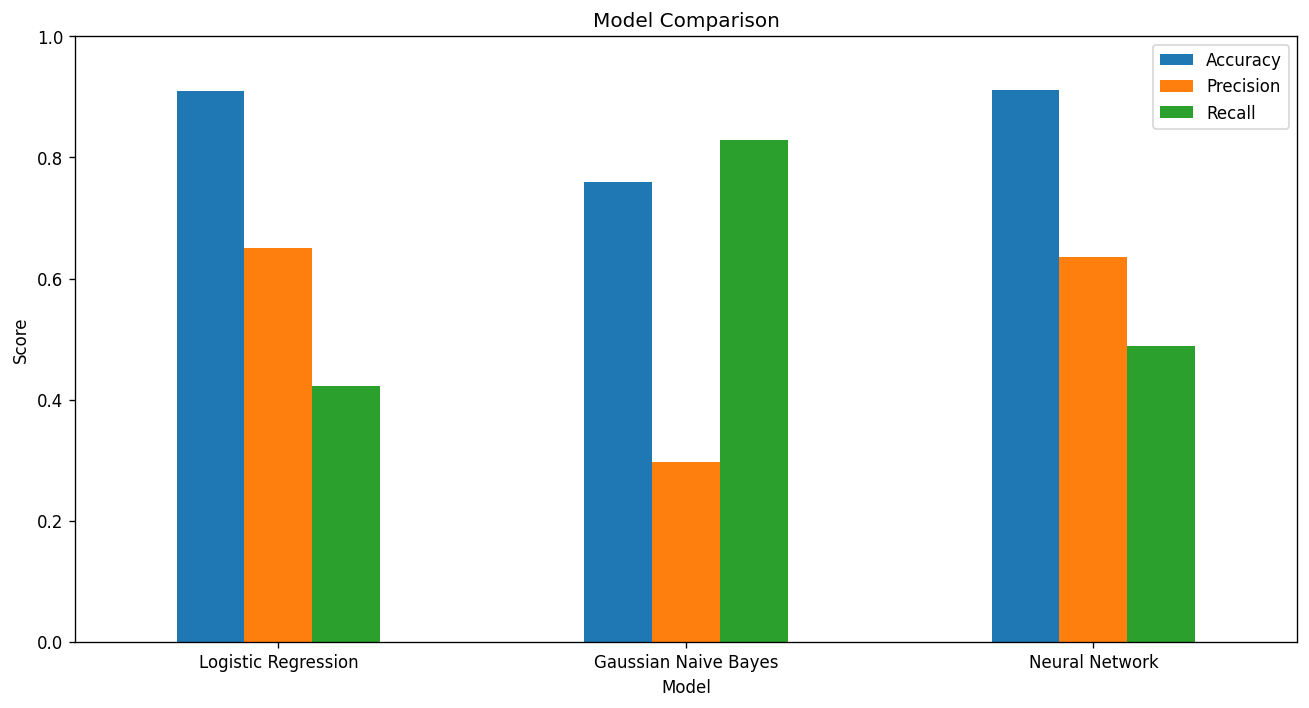

In [23]:
result.set_index('Model')[['Accuracy', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(11, 6)
)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

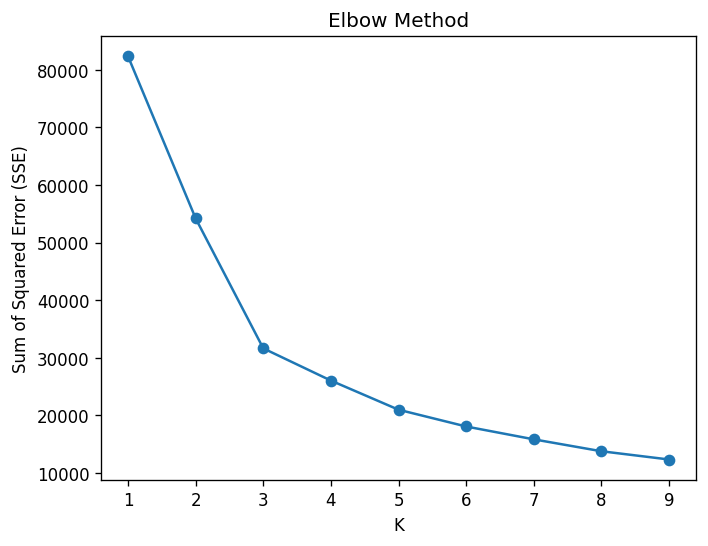

In [24]:
cluster_data = data[['age', 'duration']].copy()

k_scaler = StandardScaler()
cluster_scaled = k_scaler.fit_transform(cluster_data)

k_range = range(1, 10)
SSE = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    SSE.append(km.inertia_)

plt.plot(k_range, SSE, marker='o')
plt.xlabel("K")
plt.ylabel("Sum of Squared Error (SSE)")
plt.title("Elbow Method")
plt.xticks(list(k_range))
plt.show()

In [25]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster = km.fit_predict(cluster_scaled)

cluster_df = data.copy()
cluster_df['Cluster'] = cluster

print(cluster_df['Cluster'].value_counts().sort_index())

Cluster
0     3912
1    23513
2    13751
Name: count, dtype: int64


In [26]:
cluster_profile = cluster_df.groupby('Cluster')[['age', 'duration']].mean().round(2)
print("Cluster profile:")
print(cluster_profile)

cluster_target = pd.crosstab(
    cluster_df['Cluster'], cluster_df['y'], normalize='index'
) * 100
cluster_target.columns = ['No (%)', 'Yes (%)']

print("\nTarget percentage in each cluster:")
cluster_target.round(2)

Cluster profile:
           age  duration
Cluster                 
0        38.68    874.74
1        33.48    189.89
2        51.59    199.96

Target percentage in each cluster:


,No (%),Yes (%)
Cluster,,
0,54.27,45.73
1,92.81,7.19
2,91.56,8.44


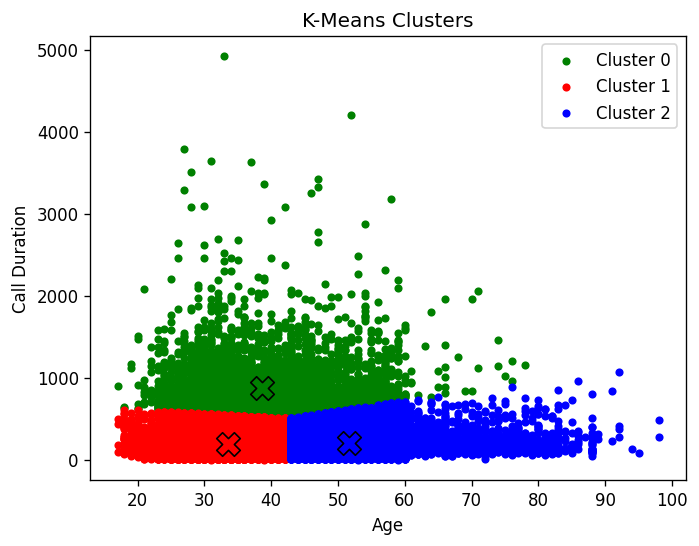

In [27]:
colors = ['green', 'red', 'blue']
center = k_scaler.inverse_transform(km.cluster_centers_)

for i in range(3):
    plt.scatter(
        cluster_data.loc[cluster == i, 'age'],
        cluster_data.loc[cluster == i, 'duration'],
        color=colors[i], s=15, label='Cluster ' + str(i)
    )
    plt.scatter(
        center[i, 0], center[i, 1],
        color=colors[i], s=200, marker='X', edgecolor='black'
    )

plt.xlabel("Age")
plt.ylabel("Call Duration")
plt.title("K-Means Clusters")
plt.legend()
plt.show()